In [1]:
import scanpy as sc # main single-cell analysis toolkit
import matplotlib.pyplot as plt # plotting
import leidenalg # Clustering algorithm
import igraph # Graph processing (used by leidenalg)
import numpy as np # Numerical operations

In [2]:
adata = sc.datasets.pbmc3k() # Load PMBC 3k dataset (3,000 blood cells)
adata.raw = adata # Preserve raw counts before processing

# annotate MT genes
adata.var["mt"] = adata.var_names.str.startswith("MT-") # Flag mitochondrial genes

# calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

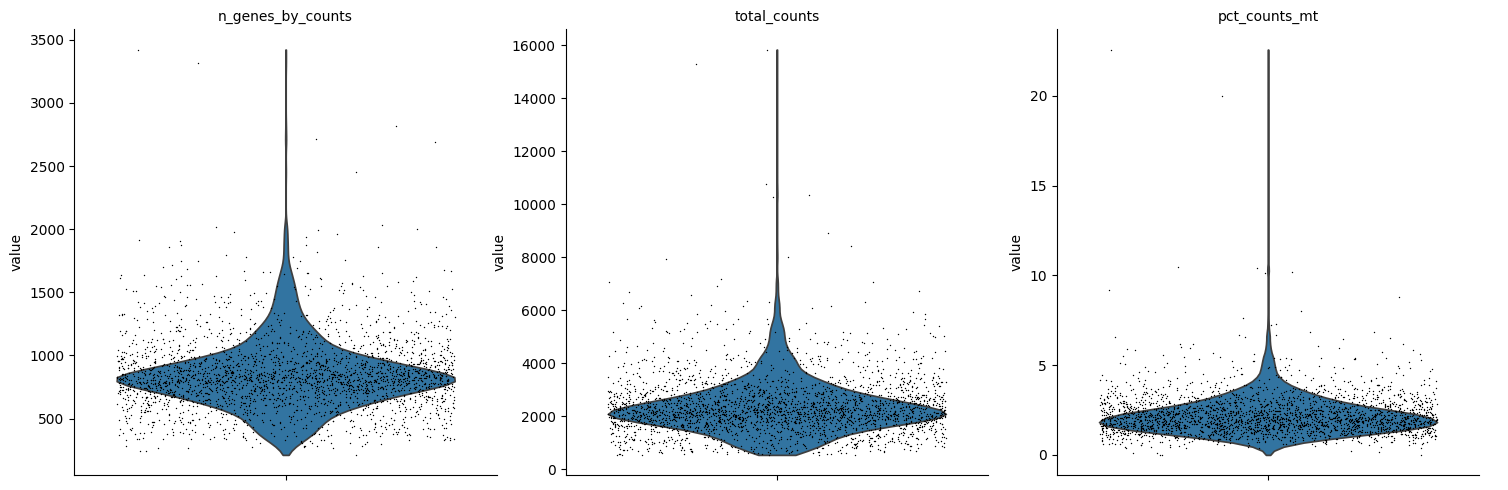

In [3]:
# plot number of genes/cell
# shows distributions of QC metrics with jittered points
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts",
                       "pct_counts_mt"],
               jitter=0.4, multi_panel=True)

In [4]:
# Filtering cells that express more than 200 genes but less than 2000
# Filtering percent mitochondrial count of less than 5
adata = adata[adata.obs.n_genes_by_counts > 200, :] # remove low-complexity cells
adata = adata[adata.obs.n_genes_by_counts < 2000, :] # remove potential doublets
adata = adata[adata.obs.pct_counts_mt < 5, :] # remove cells with high mitochondrial content

#### Unsupervised cell clustering with PCA

In [5]:
# normalize total counts to 10,000
sc.pp.normalize_total(adata, target_sum=1e4) # Scale counts to 10,000 per cell

# log transform
sc.pp.log1p(adata) # Log-transform (log1p = log(1+x))

# identify highly-variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125,
                            max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable] # Keep only the highly variable genes

# scale each gene to unit variance and zero mean, clip extreme values to +- 10
sc.pp.scale(adata, max_value=10) # Center to mean=0, variance=1 (clip outliers to +- 10)

# perform PCA
sc.tl.pca(adata, svd_solver="arpack") # Reduce to 50 PCs by default


/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


/home/merlin/Documents/Programming/the_missing_semester/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_90809/3501071956.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5) # Graph-based clustering


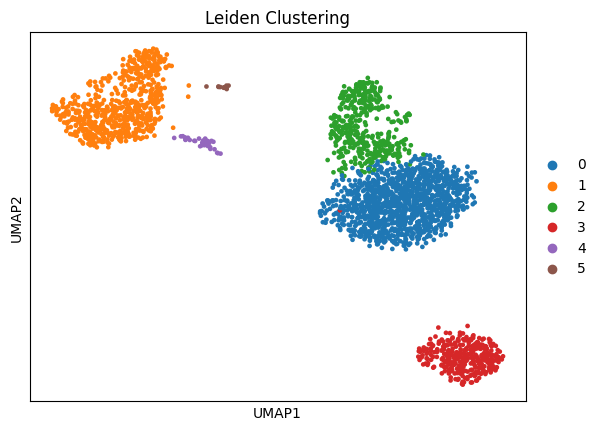

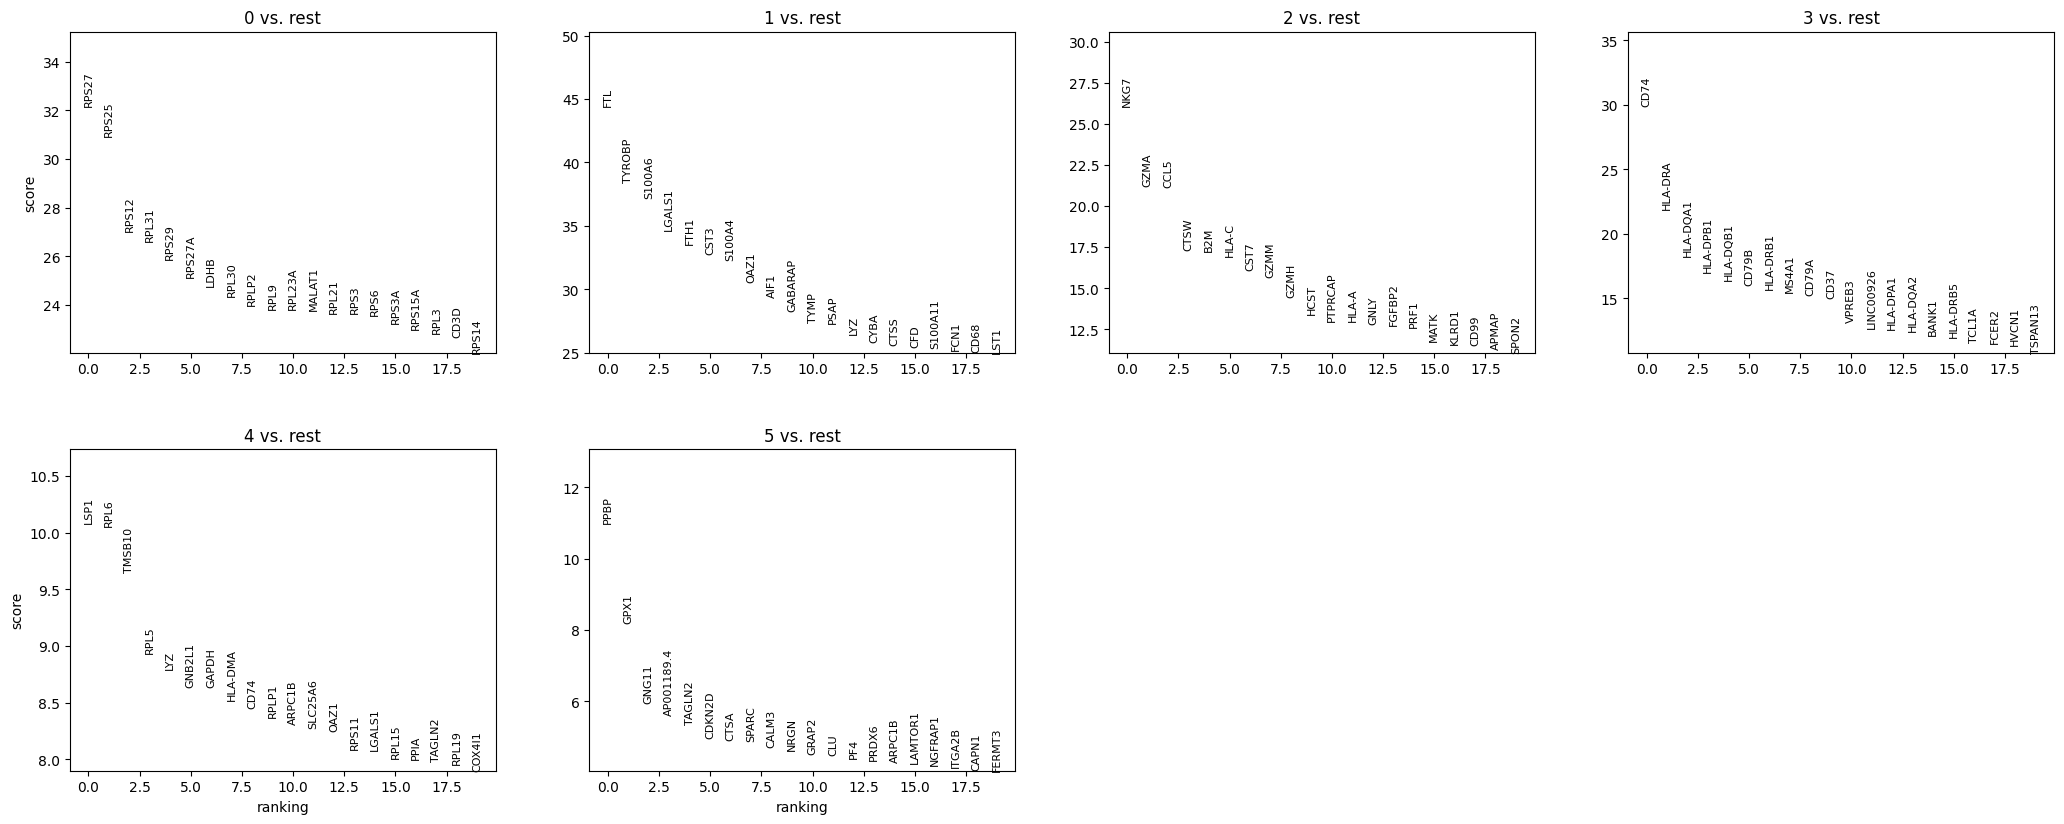

In [6]:
# set nearest nieghbors and compute UMAP
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40) # Build KNN graph using 40 PCs
sc.tl.umap(adata) # Non-linear dimensionality reduction

# perform leiden clustering
sc.tl.leiden(adata, resolution=0.5) # Graph-based clustering
sc.pl.umap(adata, color=['leiden'], title='Leiden Clustering') # Visualize clusters

sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False) # Top 20 markers per cluster

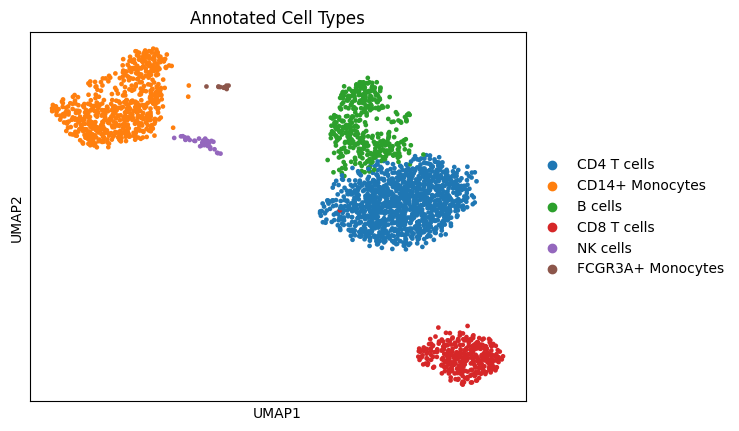

In [7]:
# manually annotate clusters (using canonical markers)
cluster_annotations = {
    '0': 'CD4 T cells', # Helper T-cells
    '1': 'CD14+ Monocytes', # Inflammatory monocytes
    '2': 'B cells', # Antibody-producing cells
    '3': 'CD8 T cells', # Cytotoxic T cells
    '4': 'NK cells', # Natural Killer cells
    '5': 'FCGR3A+ Monocytes', # Patrolling monocytes
    '6': 'Dendritic cells', # Antigen-presenting cells
    '7': 'Megakaryocytes', # Platelent precursors (ALSO trailing comma is good practice)
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotations)
sc.pl.umap(adata, color = ['cell_type'], title = 'Annotated Cell Types') # View annotated cell types
